## Bath_dMFA_2026 Software 9 — Sensitivity analysis

> Rick Lupton, University of Bath (June 2026)

In the previous notebooks, we turned the model's original single best-guess
answer into a *band* of plausible results: the question was **how wide** that
band is, or **how much uncertainty** we think there is.

Now, we're focusing on the next question:

> **Where is the uncertainty coming from?** Which inputs make the result
    uncertain, and which barely matter and could be fixed at their best guess?

Answering this is what **sensitivity analysis** aims to do. Specifically, there
are two separate 'sensitivity analysis settings' where you might have slightly
different aims:

- Where better data would help most to reduce uncertainty? (*factor
  prioritisation*)
- Where can we simplify by assuming inputs are fixed, without losing
  uncertainty? (*factor fixing*)

You might have already started to explore this in previous notebooks, by seeing
what happens when adjusting the uncertainty assumptions for different parameters
in the Monte Carlo simulation. Here, we'll make this a bit more systematic. In
particular we'll explore how the sensitivity is dependent on which outputs
you're looking at, and that it is dependent on the input uncertainty assumptions
you make. Depending on the model, *interactions* between parameters can be
important.

Outline:

- **Section 1 — setup.** Reload the model (same stock-driven model as before)
  and set up the sampling based on *input factors*.
- **Section 2 — exploratory sensitivity analysis** from Monte Carlo samples:
  scatter plots and correlations.
- **Section 3 — sensitivity depending on input assumptions**.
- **Section 4 — interactions**.
- **Section 5 — Morris and Sobol** (optional): brief introduction to more
  systematic sensitivity analysis methods.

## Setup

Same data and same stock-driven model as Notebooks 7–8 — treat it as given. We
load the future scenario drivers and the fixed historic fleet, and redefine the
model function.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats
from scipy.special import gamma

DATA = "../data/Bath_dMFA_2026_Software_Data.xlsx"
RESULTS2 = "../data/Bath_dMFA_2026_Software_2_Results.xlsx"

# Future scenario drivers (2025-2060), best-guess values:
P0 = pd.read_excel(DATA, sheet_name="Population", index_col=0).values[:, 0] * 1e6   # people
pCV0 = pd.read_excel(DATA, sheet_name="Passenger_km", index_col=0).values[:, 0]     # p-km per capita / yr
OR0 = pd.read_excel(DATA, sheet_name="Occupancy rate", index_col=0).values[:, 0]    # persons per car
IU0 = pd.read_excel(DATA, sheet_name="Kilometrage", index_col=0).values[35:, 0]     # km per vehicle / yr

BEVshare_cT = pd.read_excel(DATA, sheet_name="BEV_share", index_col=0).values        # (71, 2), %
life0 = pd.read_excel(DATA, sheet_name="Lifetime", index_col=0).values[0].astype(float)
I_c = pd.read_excel(DATA, sheet_name="New registration", index_col=0).values[:, 0]   # historic inflow

# Fixed historic fleet (1990-2024) from Notebook 2, used to initialise the projection:
HIST_S = np.zeros((71, 71, 2))
HIST_S[0:35, 0:35, 0] = pd.read_excel(RESULTS2, sheet_name="Stock_tc_gasoline", index_col=0).values
HIST_S[0:35, 0:35, 1] = pd.read_excel(RESULTS2, sheet_name="Stock_tc_BEVs", index_col=0).values
HIST_O = np.zeros((71, 71, 2))
HIST_O[0:35, 0:35, 0] = pd.read_excel(RESULTS2, sheet_name="Outflow_tc_gasoline", index_col=0).values
HIST_O[0:35, 0:35, 1] = pd.read_excel(RESULTS2, sheet_name="Outflow_tc_BEVs", index_col=0).values
HIST_IcT = np.zeros((71, 2))
HIST_IcT[0:35] = np.einsum("c,cT->cT", I_c, BEVshare_cT[0:35, :]) / 100

years_full = np.arange(1990, 2061)   # 71 years, for plotting

In [2]:
def lifetime_pdf(lifetime, sigma_frac, pdf_kind):
    """Discard probability by age (shape (2, 71)) for the two technologies."""
    ages = np.arange(71)
    tau = np.asarray(lifetime, float).reshape(2, 1)
    if pdf_kind == "normal":
        return scipy.stats.norm.pdf(ages, tau, sigma_frac * tau)
    elif pdf_kind == "weibull":
        shape = 2.0
        scale = tau / gamma(1 + 1 / shape)
        return scipy.stats.weibull_min.pdf(ages, shape, scale=scale)
    raise ValueError(f"unknown pdf_kind: {pdf_kind}")


def run_stock_driven_model(P_t, pCV_t, OR_t, IU_t, bev_share, lifetime, sigma_frac=0.3, pdf_kind="normal"):
    """Stock-driven projection (Notebook 3/7) over 1990-2060.

    Returns inflow_cT (71, 2), stock_tcT (71, 71, 2), outflow_tcT (71, 71, 2).
    """
    S_future = P_t * pCV_t / (OR_t * IU_t)           # required total fleet size, 2025-2060
    pdf = lifetime_pdf(lifetime, sigma_frac, pdf_kind)

    inflow_cT = HIST_IcT.copy()                      # start from the fixed historic fleet
    stock_tcT = HIST_S.copy()
    outflow_tcT = HIST_O.copy()

    for year in range(35, 71):                       # for all future years (2025-2060)
        stock_tcT[year, :, :] = stock_tcT[year - 1, :, :]
        for drivetech in range(2):
            leave = np.zeros(71)
            for age_cohort in range(year + 1):
                leave[age_cohort] = inflow_cT[age_cohort, drivetech] * pdf[drivetech, year - age_cohort]
            stock_tcT[year, :, drivetech] -= leave
            outflow_tcT[year, :, drivetech] += leave
        gap = S_future[year - 35] - stock_tcT[year, :, :].sum()   # shortfall vs the demand
        inflow_cT[year, :] = gap * bev_share[year, :] / 100       # new registrations fill the gap
        stock_tcT[year, year, :] = inflow_cT[year, :]

    return inflow_cT, stock_tcT, outflow_tcT

### Varying an input by a *factor*

To ask "how sensitive is the result to travel demand?", we need to turn travel
demand up and down by a controlled amount. But "travel demand" is a whole
time series (36 future years), not one number. The simplest way to scale it is
to multiply the entire best-guess trajectory by a single factor: a factor of
`1.1` means "10 % higher than best guess, in every year".

For example, travel demand 10 % higher, everything else at best guess: 

In [3]:
inflow, stock, outflow = run_stock_driven_model(P0, 1.10 * pCV0, OR0, IU0, BEVshare_cT, life0)
print(f"2060 outflow with pCV +10%:  {outflow.sum(axis=(1, 2))[70]:,.0f}")

inflow, stock, outflow = run_stock_driven_model(P0, pCV0, OR0, IU0, BEVshare_cT, life0)   # best guess
print(f"2060 outflow at best guess:  {outflow.sum(axis=(1, 2))[70]:,.0f}")

2060 outflow with pCV +10%:  12,503,164
2060 outflow at best guess:  11,365,780


> Scaling the whole trajectory by one factor like this is exactly the same as
  the "shared across years" sampling from Notebook 8.

For simplicity, initially we will treat four parameters as uncertain — travel
demand `pCV`, occupancy `OR`, kilometrage `IU` and mean `life`time — each scaled
by its own factor, and leave other parameters at their best-guess values.

## Section 2 — Exploratory sensitivity analysis

A good place to start understanding sensitivities is simply to plot the
relationships between parameters and outputs, using the Monte Carlo samples
we've already generated: if, across the samples, the output rises and falls in
step with one input, the output is **sensitive** to that input; if it ignores an
input that is varying a lot, it is **insensitive** to it.

Here are the steps:

1. Monte Carlo sampling — similar to before, but now we need to also keep track
   of the sampled input factors, not only the sampled outputs.
2. Visualisation with scatter plots.
3. Quantification with correlations.
4. Sensitivity to different outputs.

> **Predict first**: for the *2060 outflow* (end-of-life vehicles),
> which of the four factors — `pCV`, `OR`, `IU`, `life` — do you expect to drive
> the uncertainty range the most? Consider how these parameters enter the
  calculation of `S_future` in the `run_stock_driven_model` function.
>
> Would your answer change for a different output, like the
> **2050 BEV share** of the fleet?
>
> Write your thoughts below.

### Step 1 — Monte Carlo sampling, keeping input factors

The function below is the same sample → run → collect loop as in Notebook 8,
based on the "shared" sampling: one uncertainty factor adjusts data values in
all years together. The differences is that it returns the sampled factors
alongside the outputs so we can correlate them.

In [4]:
def run_factor_ensemble(rng, cv_pCV, cv_OR, cv_IU, cv_life, N=1500):
    """
    Draw N samples of each factor (a multiplier on a parameters's whole
    trajectory), run the model on each, and return the sampled factors and two
    outputs.
    """
    f_pCV = rng.normal(1.0, cv_pCV, N)
    f_OR = rng.normal(1.0, cv_OR, N)
    f_IU = rng.normal(1.0, cv_IU, N)
    f_life = np.clip(rng.normal(1.0, cv_life, N), 0.2, None)   # keep lifetimes positive

    outflow_2060 = np.zeros(N)
    bev_share_2050 = np.zeros(N)
    for i in range(N):
        inflow, stock, outflow = run_stock_driven_model(
            P0, pCV0 * f_pCV[i], OR0 * f_OR[i], IU0 * f_IU[i], BEVshare_cT, life0 * f_life[i])
        outflow_2060[i] = outflow.sum(axis=(1, 2))[70]
        stock_tT = stock.sum(1)
        bev_share_2050[i] = 100 * stock_tT[60, 1] / stock_tT[60].sum()
    return f_pCV, f_OR, f_IU, f_life, outflow_2060, bev_share_2050

Try it first with an arbitrary set of input uncertainty spreads. We'll test later how the
results differ with different assumptions about these uncertainties.

In [5]:
rng = np.random.default_rng(20260701)
f_pCV, f_OR, f_IU, f_life, outflow_2060, bev_share_2050 = run_factor_ensemble(
    rng, cv_pCV=0.14, cv_OR=0.09, cv_IU=0.09, cv_life=0.20)
print("ensemble size:", outflow_2060.shape)

ensemble size: (1500,)


### Step 2 — visualising outputs vs factors

A good start is simply to look at the scatter plots of outputs vs input factors.
a strong up- or down-slope means the output is sensitive to that factor; a
shapeless blob means it is not. However, we do not typically see a clean
relationship since all the *other* factors are varying at every point too: this
is why the clouds have a spread rather than lying on a clean line. 

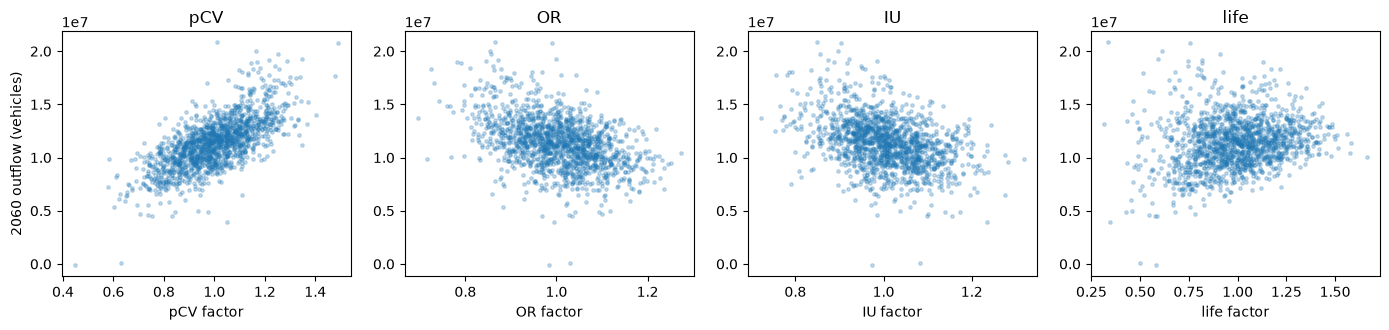

In [6]:
fig, ax = plt.subplots(1, 4, figsize=(14, 3.4))
for a, name, factor in zip(ax, ["pCV", "OR", "IU", "life"], [f_pCV, f_OR, f_IU, f_life]):
    a.scatter(factor, outflow_2060, s=6, alpha=0.25, color="C0")
    a.set_xlabel(f"{name} factor")
    a.set_title(name)
ax[0].set_ylabel("2060 outflow (vehicles)")
fig.tight_layout();

> **Exercise:** which outputs is the 2060 outflow most sensitive to?

> **Exercise:** plot a similar set of scatter plots for the 2050 BEV share
    `bev_share_2050`.  Is this output sensitive to the same factors?

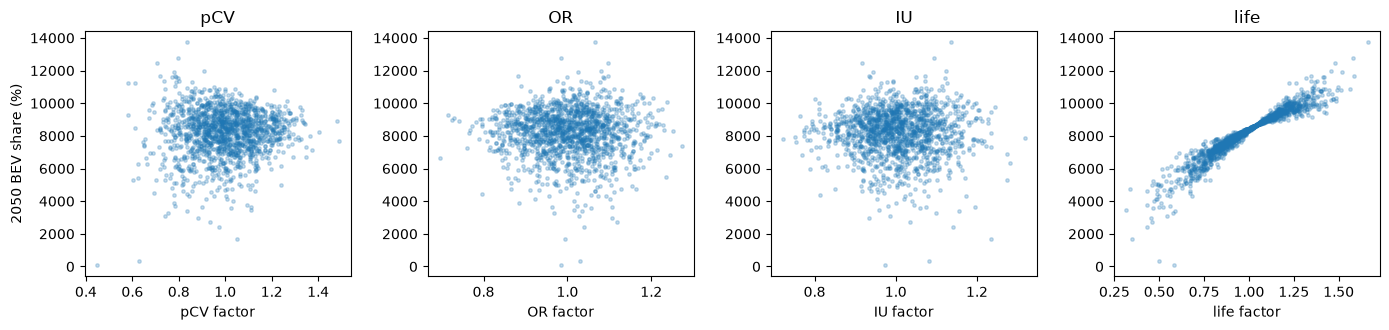

In [7]:
fig, ax = plt.subplots(1, 4, figsize=(14, 3.4))
for a, name, factor in zip(ax, ["pCV", "OR", "IU", "life"], [f_pCV, f_OR, f_IU, f_life]):
    a.scatter(factor, 100 * bev_share_2050, s=6, alpha=0.25, color="C0")
    a.set_xlabel(f"{name} factor")
    a.set_title(name)
ax[0].set_ylabel("2050 BEV share (%)")
fig.tight_layout();

### Step 3 — quantification: correlation

While the plots are helpful to understand the behaviour of the model and
uncertainty in different outputs, it's also helpful to have quantitative
metrics. A simple summary is the **correlation coefficient** between each factor
and the output: near ±1 means the output tracks that factor closely, near 0
means it ignores it.

**Your turn:** compute the correlation for each factor with the 2060 outflow.

*Hint:* `np.corrcoef(a, b)` is the correlation *matrix* of two arrays. The
diagonals of this matrix are the self-correlation of `a` and `b` respectively,
which are equal to +1 by definition; the off-diagonal elements give the
correlation between `a` and `b`. 

In [8]:
for name, factor in [("pCV", f_pCV), ("OR", f_OR), ("IU", f_IU), ("life", f_life)]:
    r = np.corrcoef(factor, outflow_2060)[0, 1]
    print(f"{name:5s}  correlation with 2060 outflow = {r:+.2f}")

pCV    correlation with 2060 outflow = +0.70
OR     correlation with 2060 outflow = -0.43
IU     correlation with 2060 outflow = -0.40
life   correlation with 2060 outflow = +0.19


> **Exercise:** assume you have the opportunity to do some further research to
> narrow the uncertainty range of one of the parameters, but you only have time to
> investigate at one. Which one would you prioritise, based on these results?

> **Exercise:** Repeat the correlation calculation for the 2050 BEV share. How
    does the ranking differ?

## Section 3 — Sensitivity depends on uncertainty assumptions

The sensitivities we've seen above depend on two things: how strongly the model
responds to that parameter, and how uncertain it is. Roughly:

> importance ≈ (how much the output moves per unit of input) × (how uncertain
> the input is)

The second term is the estimated uncertainty, which as we've already seen can be
somewhat arbitrary (based on e.g. data quality assessment methods). So the
sensitivity importance ranking is **conditional on those input-uncertainty
assumptions**, not a fixed property of the model. 

### Example: travel demand and occupancy.

Travel demand `pCV` and occupancy `OR` enter the required fleet size
symmetrically: `S = P · pCV / (OR · IU)`. The model is equally responsive to
relative changes in either parameter; which one comes out "more important" is
therefore decided *entirely* by which parameter is attributed higher
uncertainty.

> **Exercise:** Re-run the ensemble sampling twice again, using
> `run_factor_ensemble` as above, to compare these two cases: **(A)** CV for `pCV`
> of 18%, and 5% for `OR`; **(B)** same values but swapped around.
>
> Repeat the scatter plots and correlation analysis twice, for each of these new
> samples.  How does the sensitivity ranking change? 

In [9]:
rng = np.random.default_rng(20260701)
f_pCV_A, f_OR_A, f_IU_A, f_life_A, outflow_2060_A, bev_share_2050_A = \
    run_factor_ensemble(rng, cv_pCV=0.18, cv_OR=0.05, cv_IU=0.05, cv_life=0.10)

rng = np.random.default_rng(20260701)
f_pCV_B, f_OR_B, f_IU_B, f_life_B, outflow_2060_B, bev_share_2050_B = \
    run_factor_ensemble(rng, cv_pCV=0.05, cv_OR=0.18, cv_IU=0.05, cv_life=0.10)

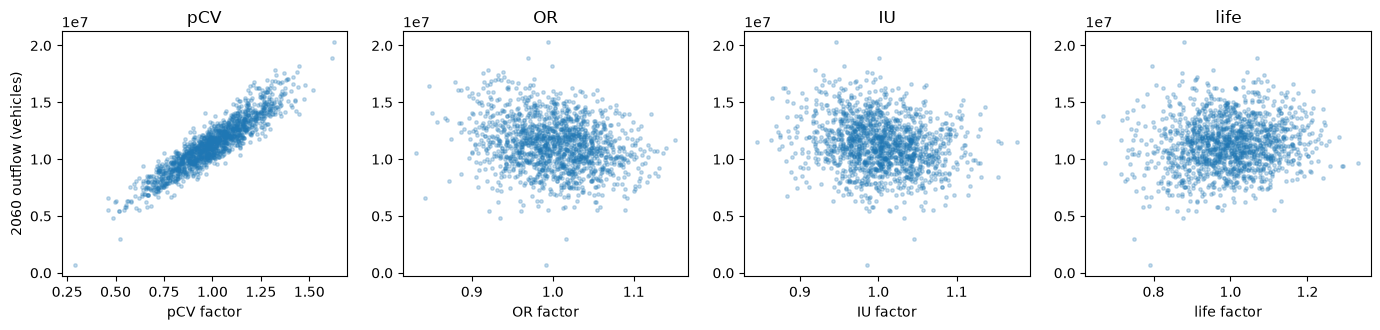

In [10]:
fig, ax = plt.subplots(1, 4, figsize=(14, 3.4))
for a, name, factor in zip(ax, ["pCV", "OR", "IU", "life"], [f_pCV_A, f_OR_A, f_IU_A, f_life_A]):
    a.scatter(factor, outflow_2060_A, s=6, alpha=0.25, color="C0")
    a.set_xlabel(f"{name} factor")
    a.set_title(name)
ax[0].set_ylabel("2060 outflow (vehicles)")
fig.tight_layout();

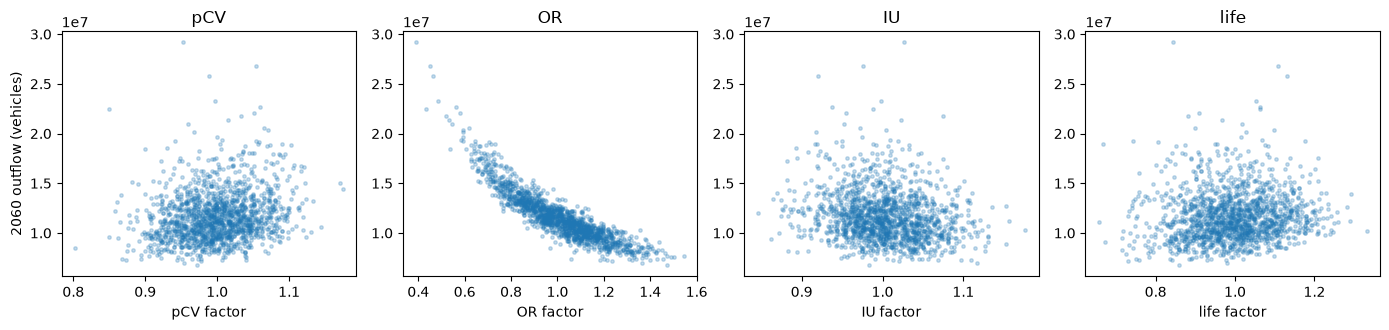

In [11]:
fig, ax = plt.subplots(1, 4, figsize=(14, 3.4))
for a, name, factor in zip(ax, ["pCV", "OR", "IU", "life"], [f_pCV_B, f_OR_B, f_IU_B, f_life_B]):
    a.scatter(factor, outflow_2060_B, s=6, alpha=0.25, color="C0")
    a.set_xlabel(f"{name} factor")
    a.set_title(name)
ax[0].set_ylabel("2060 outflow (vehicles)")
fig.tight_layout();

For case (A):

In [12]:
for name, factor in [("pCV", f_pCV_A), ("OR", f_OR_A), ("IU", f_IU_A), ("life", f_life_A)]:
    r = np.corrcoef(factor, outflow_2060_A)[0, 1]
    print(f"{name:5s}  correlation with 2060 outflow = {r:+.2f}")

pCV    correlation with 2060 outflow = +0.92
OR     correlation with 2060 outflow = -0.23
IU     correlation with 2060 outflow = -0.19
life   correlation with 2060 outflow = +0.11


For case (B):

In [13]:
for name, factor in [("pCV", f_pCV_B), ("OR", f_OR_B), ("IU", f_IU_B), ("life", f_life_B)]:
    r = np.corrcoef(factor, outflow_2060_B)[0, 1]
    print(f"{name:5s}  correlation with 2060 outflow = {r:+.2f}")

pCV    correlation with 2060 outflow = +0.21
OR     correlation with 2060 outflow = -0.90
IU     correlation with 2060 outflow = -0.19
life   correlation with 2060 outflow = +0.08


> **Optional exercise:** Try the same thing again focusing on the *lifetime*
    parameter: compare a *small* lifetime CV (say 0.05) and a *large* one (say
    0.35), keeping the other parameter CVs fixed (e.g. `cv_pCV=0.10, cv_OR=0.06,
    cv_IU=0.06`). How far does lifetime climb up the sensitivity ranking for the
    2060 outflow? Could a reader who disagreed with your uncertainty reach a
    different conclusion about the most important uncertainty sources? 

These examples show that it can be important to test the robustness of
sensitivity analysis findings, when the characterisation of uncertainty is
itself debatable. 

## Section 4 — Interactions

Everything so far gave only one sensitivity number per factor. That is fine when
each factor acts independently, but in reality the effect of one input can
depend on the value of another (an "interaction"), and a single correlation can
miss this effect.

**Why is this important?** We mentioned above that there are two ways to use
  sensitivity analysis results: *factor prioritisation* (i.e. where to focus on
  reducing uncertainty) and *factor fixing* (i.e. where can we safely conclude
  that uncertainty in a parameter is not important for a given output). The
  problem is that when parameters interact, we could wrongly conclude that a
  parameter is unimportant, when in it is important in combination with other
  parameters.

To see this visually, we can use the same scatter plot, by looking at the
output-vs-`pCV` relationship *separately* for short-lived and long-lived fleets.
To do this, we split the samples into the third of runs with the **lowest**
lifetime factor and the third with the **highest**. 

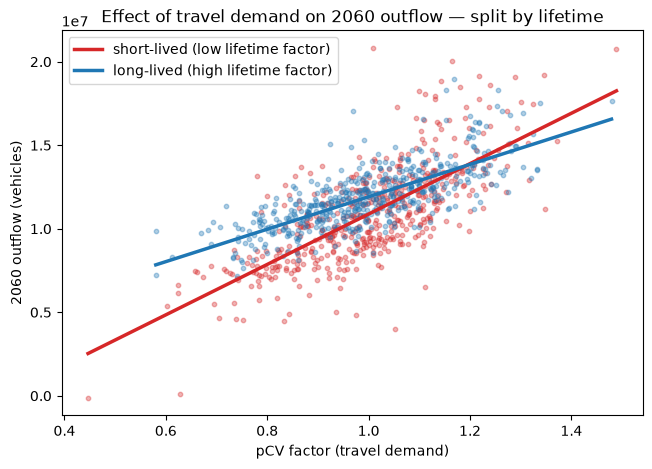

In [14]:
low_life = f_life <= np.percentile(f_life, 33)    # short-lived third of the runs
high_life = f_life >= np.percentile(f_life, 67)   # long-lived third

plt.figure(figsize=(7.5, 5))
for mask, color, label in [(low_life, "C3", "short-lived (low lifetime factor)"),
                           (high_life, "C0", "long-lived (high lifetime factor)")]:
    plt.scatter(f_pCV[mask], outflow_2060[mask], s=10, alpha=0.35, color=color)
    slope, intercept = np.polyfit(f_pCV[mask], outflow_2060[mask], 1)   # best-fit line
    xs = np.array([f_pCV[mask].min(), f_pCV[mask].max()])
    plt.plot(xs, slope * xs + intercept, color=color, lw=2.5, label=label)
plt.xlabel("pCV factor (travel demand)"); plt.ylabel("2060 outflow (vehicles)")
plt.title("Effect of travel demand on 2060 outflow — split by lifetime")
plt.legend();

The two best-fit lines have **different slopes**: travel demand drives the 2060
outflow much more steeply when vehicles are *short-lived* than when they are
*long-lived*. The importance of `pCV` depends on `life`: the two factors
interact.

> **Optional exercise:** instead of the outflow result, repeat the split-scatter
    for the 2050 BEV share against `pCV`, split by lifetime. The overall cloud
    looks flat (`pCV` barely correlates with the BEV share), so we would
    conclude that `pCV` is unimportant for the overall uncertainty. See if there
    are different trends within the short-lived and long-lived groups? Does that
    change your conclusions about the importance of this parameter?

## Section 5 — Morris (optional)

Looking for interactions manually, like in Section 4, does not scale. The
**method of Morris** aims to automate the screening. It makes changes to one
factor at a time, but does so *from many random starting points* scattered
through the whole input space, and summarises each factor with:

- **μ\*** — the mean absolute effect: an importance ranking.
- **σ** — how much that effect *varies* with where you are in the space: a large
  σ flags a factor whose influence is **non-linear or interacts with others**.

We use the [SALib](https://salib.readthedocs.io/) library, which does the
sampling and bookkeeping; we just supply a function that runs the model on each
row of factors it asks about. 

In [15]:
from SALib.sample import morris as morris_sample
from SALib.analyze import morris as morris_analyze


def run_outflow_2060(factor_rows):
    """Run the model for each row [f_pCV, f_OR, f_IU, f_life] and return the 2060 outflow."""
    Y = np.zeros(len(factor_rows))
    for i, (f_pCV, f_OR, f_IU, f_life) in enumerate(factor_rows):
        inflow, stock, outflow = run_stock_driven_model(
            P0, pCV0 * f_pCV, OR0 * f_OR, IU0 * f_IU, BEVshare_cT, life0 * f_life)
        Y[i] = outflow.sum(axis=(1, 2))[70]
    return Y


# Describe the four factors and a plausible range for each (wider for the
# loosely-known lifetime), so the result reflects our uncertainty, as in Section 3.
problem = {
    "num_vars": 4,
    "names": ["pCV", "OR", "IU", "life"],
    "bounds": [[0.75, 1.25], [0.85, 1.15], [0.85, 1.15], [0.65, 1.35]],
}

X_morris = morris_sample.sample(problem, N=80, num_levels=4, seed=1)
Y_morris = run_outflow_2060(X_morris)
Si_morris = morris_analyze.analyze(problem, X_morris, Y_morris, num_levels=4, seed=1, print_to_console=False)
print(f"{X_morris.shape[0]} model runs")
for name, mu, sig in zip(problem["names"], Si_morris["mu_star"], Si_morris["sigma"]):
    print(f"  {name:5s} mu*={mu:11.3g}   sigma={sig:11.3g}")

400 model runs
  pCV   mu*=   6.74e+06   sigma=   2.15e+06
  OR    mu*=    3.7e+06   sigma=    1.2e+06
  IU    mu*=      4e+06   sigma=   1.36e+06
  life  mu*=   2.09e+06   sigma=   2.08e+06


The standard Morris plot puts μ\* (importance) on the x-axis and σ (interactions)
on the y-axis. Factors low on the y-axis act roughly on their own; factors
high on the y-axis act *through interactions* or are non-linear in response.

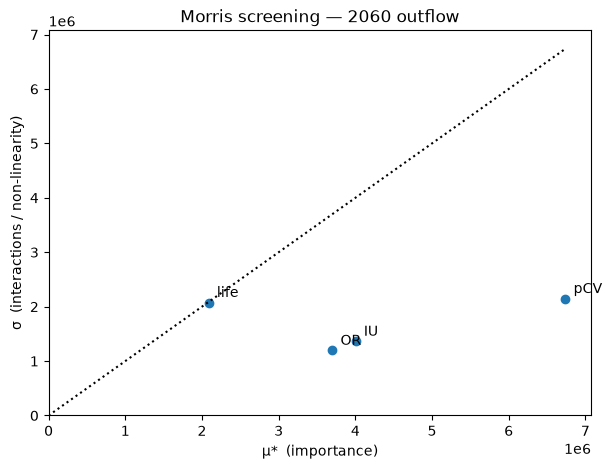

In [16]:
plt.figure(figsize=(7, 5))
plt.scatter(Si_morris["mu_star"], Si_morris["sigma"], color="C0")
for name, mu, sig in zip(problem["names"], Si_morris["mu_star"], Si_morris["sigma"]):
    plt.annotate(name, (mu, sig), textcoords="offset points", xytext=(6, 4))
plt.plot([0, max(Si_morris["mu_star"])], [0, max(Si_morris["mu_star"])], 'k:')
plt.xlabel("μ*  (importance)"); plt.ylabel("σ  (interactions / non-linearity)")
plt.title("Morris screening — 2060 outflow")
plt.xlim(left=0); plt.ylim(bottom=0);

The mean lifetime has the lowest μ\* (least important on average, as the
Section-2 correlation suggested), but the largest σ relative to its μ\*: its
effect varies wildly depending on the other factors. This is flagging the
interaction seen above in Section-4.

> **Optional exercise:** Re-run Morris for a different output (the 2050 BEV share, or the
> cumulative future outflow `outflow.sum(axis=(1, 2))[35:].sum()`) and see
> whether the ranking and the interactions change.

### The Sobol method (optional)

Morris is a screening method — it identifies potentially important parameters
and interactions, but does not quantify these in a well-defined way. The
**Sobol** method is more computationally intensive but gives a specific
quantification by splitting the output variance into contributions from each
factor.  It calculates two main results:

- **S1** (first-order index) — this sensitivity index measures the fraction of
  variance a factor explains *on its own*, similar to the correlation-based
  metric used above. This is the right index to use for factor prioritisation.
- **ST** (total-order index) — this measures the fraction of variance a factor
  is involved in explaining, *including all interactions*. This is the right
  index to use for factor fixing: a factor is safe to fix only if its `ST` is
  near zero.

Sobol requires more model evaluations than Morris, so often a sensible approach
is first to screen with the Morris method, then quantify sensitivities and
interactions for important parameters with the Sobol method. 

> **Optional exercise (advanced):** Use SALib's Sobol analysis functions to
apply the Sobol method to the same model. The SALib functions have a very
similar interface to the Morris functions, so the Morris example about should be
a good starting point, together with the SALib documentation. See how the S1 and
ST indices compare for each parameter. Do you see a similar conclusion as
before?

## Conclusions

We've seen how can use sensitivity analysis to move from quantifying the
uncertainty range, to explaining which uncertainty sources are driving it.

We can do this simply by looking at scatter plots and correlations, which
already gives a good idea of sensitivities. The rankings we get depend both on
the model structure (how it responds to changes in parameters) and our
uncertainty assumptions (which parameters can change the most), and are
different for different model outputs.

While it is a complicated problem to handle in general, we've seen a bit about
interactions and how Morris and Sobol methods can be used to screen and quantify
sensitivities more systematically.

There are a few caveats.

- **Independent factors.** Morris and Sobol as used here assume the factors are
  independent, but we've seen in Notebook 8 that this might not always be the
  case, depending how you set up your model.
- **The numbers are estimates.** They come from a finite sample and will vary a
  little for small sample sizes; check convergence or use big samples.
- **Parameter sensitivity is not the whole story.** This varies *parameters* of
  a fixed model. It cannot see the **structural** uncertainty from Notebooks
  6–7, which could be a bigger issue than specific parameter values.

> **Further optional exercises:**
> 1. Add `bev_share` (a single multiplier on the BEV column) as a fifth factor,
>    or split the lifetime into separate gasoline and BEV factors, and look for
>    new interactions.
> 2. Re-run the Morris or Sobol with a much smaller base sample and several
>    seeds, and watch how much the indices for the *small* factors jump around,
>    to get a feel for how many samples a reliable index needs.